In [22]:
from google.colab import drive
# drive.mount('/content/drive/MyDrive/DL_project') # Incorrect mountpoint
drive.mount('/content/drive') # Use the standard mountpoint

Mounted at /content/drive


In [23]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("BRAIN TUMOR MRI - DATA PREPROCESSING PIPELINE")
print("="*70)


BRAIN TUMOR MRI - DATA PREPROCESSING PIPELINE


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


📁 STEP 1: LOADING RAW DATA
----------------------------------------------------------------------
Loading glioma: 1321 images
Loading meningioma: 1339 images
Loading notumor: 1595 images
Loading pituitary: 1457 images

✅ Data loaded successfully!
   Total images: 5712
   Image shape: (5712, 224, 224, 3)
   Labels shape: (5712,)
   Data type: uint8
   Value range: [0, 255]


📊 STEP 2: EXPLORATORY DATA ANALYSIS
----------------------------------------------------------------------

Class Distribution:
     Class  Count  Percentage
    glioma   1321       23.13
meningioma   1339       23.44
   notumor   1595       27.92
 pituitary   1457       25.51

Imbalance Ratio: 1.21
✅ Classes are relatively balanced


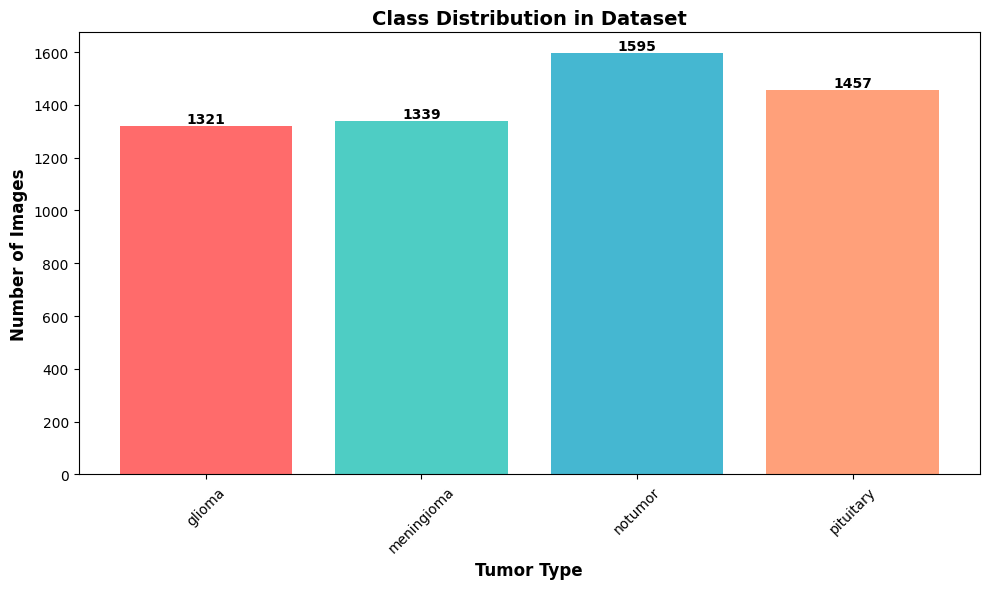


Sample Images from Each Class:


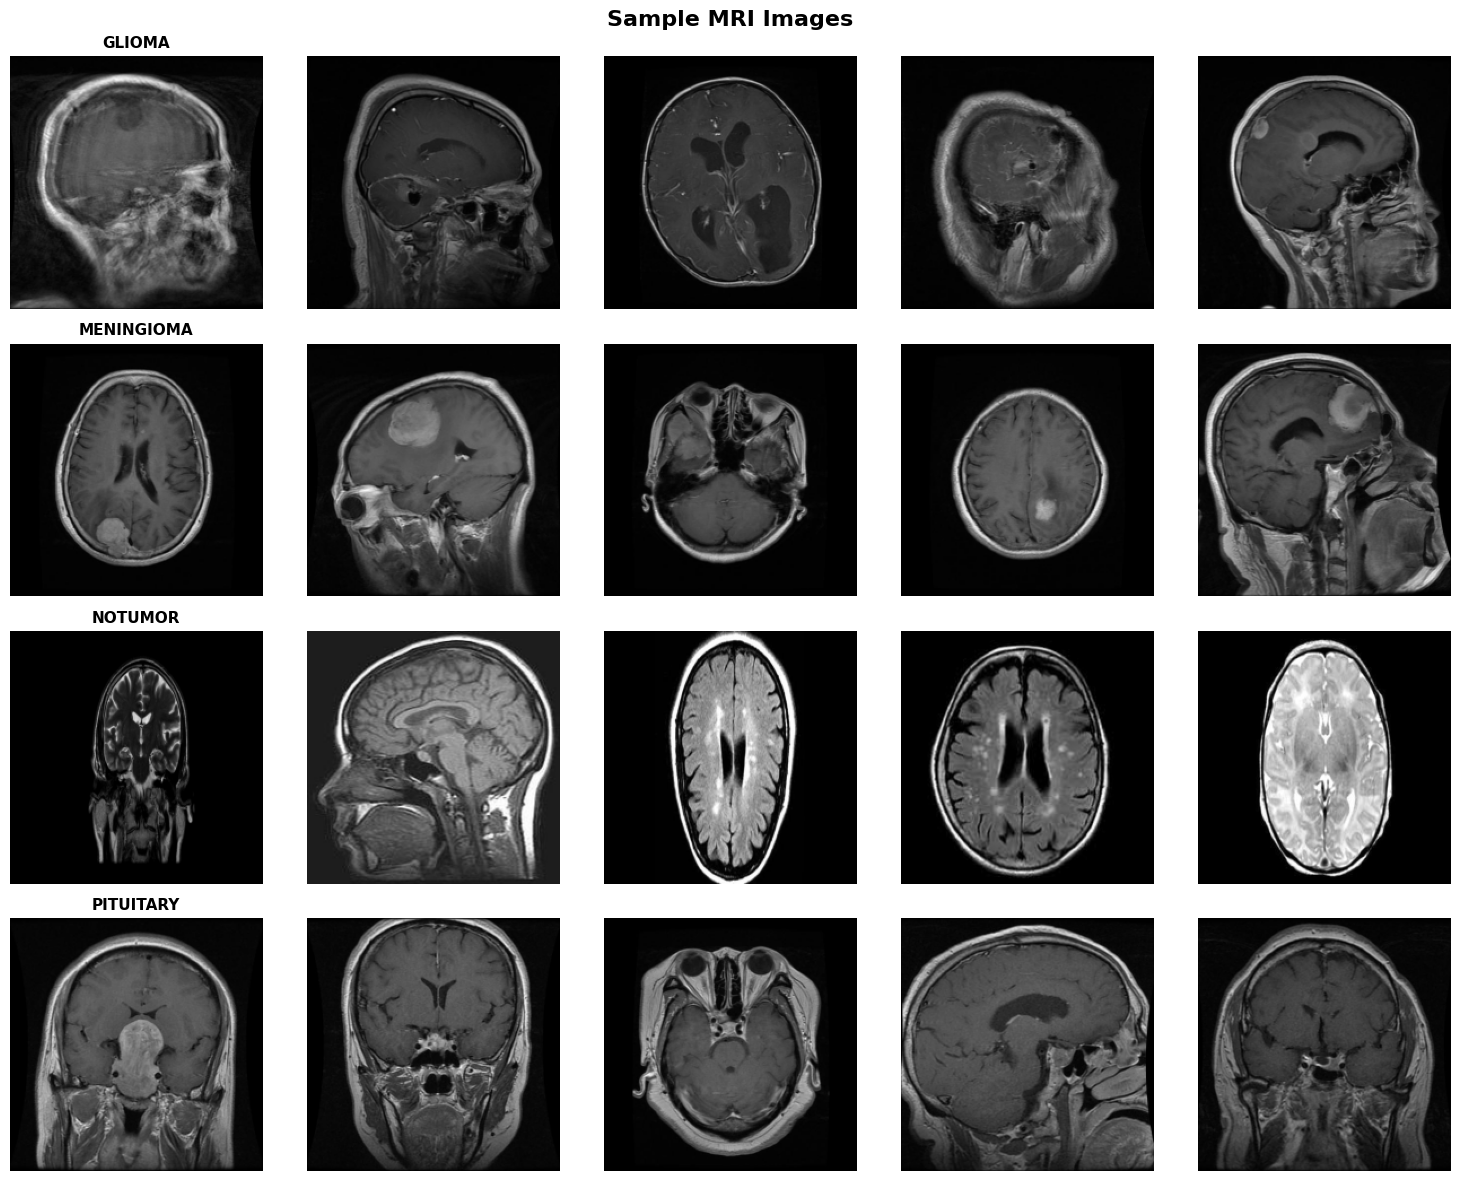

In [4]:
print("\n📁 STEP 1: LOADING RAW DATA")
print("-"*70)

DATA_DIR = '/content/data/Training'
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
IMG_SIZE = (224, 224)  # Standard size for transfer learning

def load_images_and_labels(data_dir, img_size, classes):
    """
    Load all images and labels from directory

    Returns:
        images: numpy array of images
        labels: numpy array of class indices
        file_paths: list of file paths for reference
    """
    images = []
    labels = []
    file_paths = []

    for class_idx, class_name in enumerate(classes):
        class_path = os.path.join(data_dir, class_name)

        if not os.path.exists(class_path):
            print(f"⚠️ Warning: {class_path} not found!")
            continue

        image_files = os.listdir(class_path)
        print(f"Loading {class_name}: {len(image_files)} images")

        for img_name in image_files:
            img_path = os.path.join(class_path, img_name)

            try:
                # Read image
                img = cv2.imread(img_path)

                if img is None:
                    print(f"  ⚠️ Failed to load: {img_name}")
                    continue

                # Convert BGR to RGB (OpenCV loads as BGR)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # Resize to standard size
                img = cv2.resize(img, img_size, interpolation=cv2.INTER_AREA)

                images.append(img)
                labels.append(class_idx)
                file_paths.append(img_path)

            except Exception as e:
                print(f"  ❌ Error loading {img_name}: {str(e)}")

    return np.array(images), np.array(labels), file_paths

# Load data
X_raw, y_raw, file_paths = load_images_and_labels(DATA_DIR, IMG_SIZE, CLASSES)

print(f"\n✅ Data loaded successfully!")
print(f"   Total images: {len(X_raw)}")
print(f"   Image shape: {X_raw.shape}")
print(f"   Labels shape: {y_raw.shape}")
print(f"   Data type: {X_raw.dtype}")
print(f"   Value range: [{X_raw.min()}, {X_raw.max()}]")

# ============================================
# STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================
print("\n\n📊 STEP 2: EXPLORATORY DATA ANALYSIS")
print("-"*70)

# Class distribution
unique, counts = np.unique(y_raw, return_counts=True)
class_distribution = pd.DataFrame({
    'Class': [CLASSES[i] for i in unique],
    'Count': counts,
    'Percentage': (counts / len(y_raw) * 100).round(2)
})

print("\nClass Distribution:")
print(class_distribution.to_string(index=False))

# Check for class imbalance
max_count = counts.max()
min_count = counts.min()
imbalance_ratio = max_count / min_count
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}")
if imbalance_ratio > 2:
    print("⚠️ Significant class imbalance detected!")
else:
    print("✅ Classes are relatively balanced")

# Visualize distribution
plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = plt.bar(class_distribution['Class'], class_distribution['Count'], color=colors)
plt.xlabel('Tumor Type', fontsize=12, fontweight='bold')
plt.ylabel('Number of Images', fontsize=12, fontweight='bold')
plt.title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Display sample images
print("\nSample Images from Each Class:")
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('Sample MRI Images', fontsize=16, fontweight='bold')

for class_idx, class_name in enumerate(CLASSES):
    class_indices = np.where(y_raw == class_idx)[0]
    sample_indices = np.random.choice(class_indices, 5, replace=False)

    for i, idx in enumerate(sample_indices):
        axes[class_idx, i].imshow(X_raw[idx])
        axes[class_idx, i].axis('off')
        if i == 0:
            axes[class_idx, i].set_title(f'{class_name.upper()}',
                                         fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

In [5]:
print("\n\n🔍 STEP 3: DATA QUALITY CHECKS")
print("-"*70)

def check_data_quality(images, labels):
    """Check for data quality issues"""
    issues = []

    # Check for duplicate images
    print("Checking for duplicates...")
    unique_images = np.unique(images.reshape(len(images), -1), axis=0)
    if len(unique_images) < len(images):
        duplicates = len(images) - len(unique_images)
        issues.append(f"Found {duplicates} duplicate images")
    else:
        print("✅ No duplicates found")

    # Check for corrupted images (all black or all white)
    print("Checking for corrupted images...")
    corrupted = 0
    for i, img in enumerate(images):
        if np.all(img == 0) or np.all(img == 255):
            corrupted += 1
            issues.append(f"Corrupted image at index {i}")

    if corrupted == 0:
        print("✅ No corrupted images found")
    else:
        print(f"⚠️ Found {corrupted} corrupted images")

    # Check image statistics
    print("\nImage Statistics:")
    print(f"  Mean pixel value: {images.mean():.2f}")
    print(f"  Std pixel value: {images.std():.2f}")
    print(f"  Min pixel value: {images.min()}")
    print(f"  Max pixel value: {images.max()}")

    return issues

quality_issues = check_data_quality(X_raw, y_raw)

if quality_issues:
    print("\n⚠️ Quality Issues Found:")
    for issue in quality_issues:
        print(f"  - {issue}")
else:
    print("\n✅ All quality checks passed!")



🔍 STEP 3: DATA QUALITY CHECKS
----------------------------------------------------------------------
Checking for duplicates...
Checking for corrupted images...
✅ No corrupted images found

Image Statistics:
  Mean pixel value: 47.27
  Std pixel value: 51.31
  Min pixel value: 0
  Max pixel value: 255

⚠️ Quality Issues Found:
  - Found 207 duplicate images




🔧 STEP 4: IMAGE PREPROCESSING
----------------------------------------------------------------------
Preprocessing images...
  Processed 1000/5712 images
  Processed 2000/5712 images
  Processed 3000/5712 images
  Processed 4000/5712 images
  Processed 5000/5712 images

✅ Preprocessing complete!
   Preprocessed shape: (5712, 224, 224, 3)

Comparing Original vs Preprocessed:


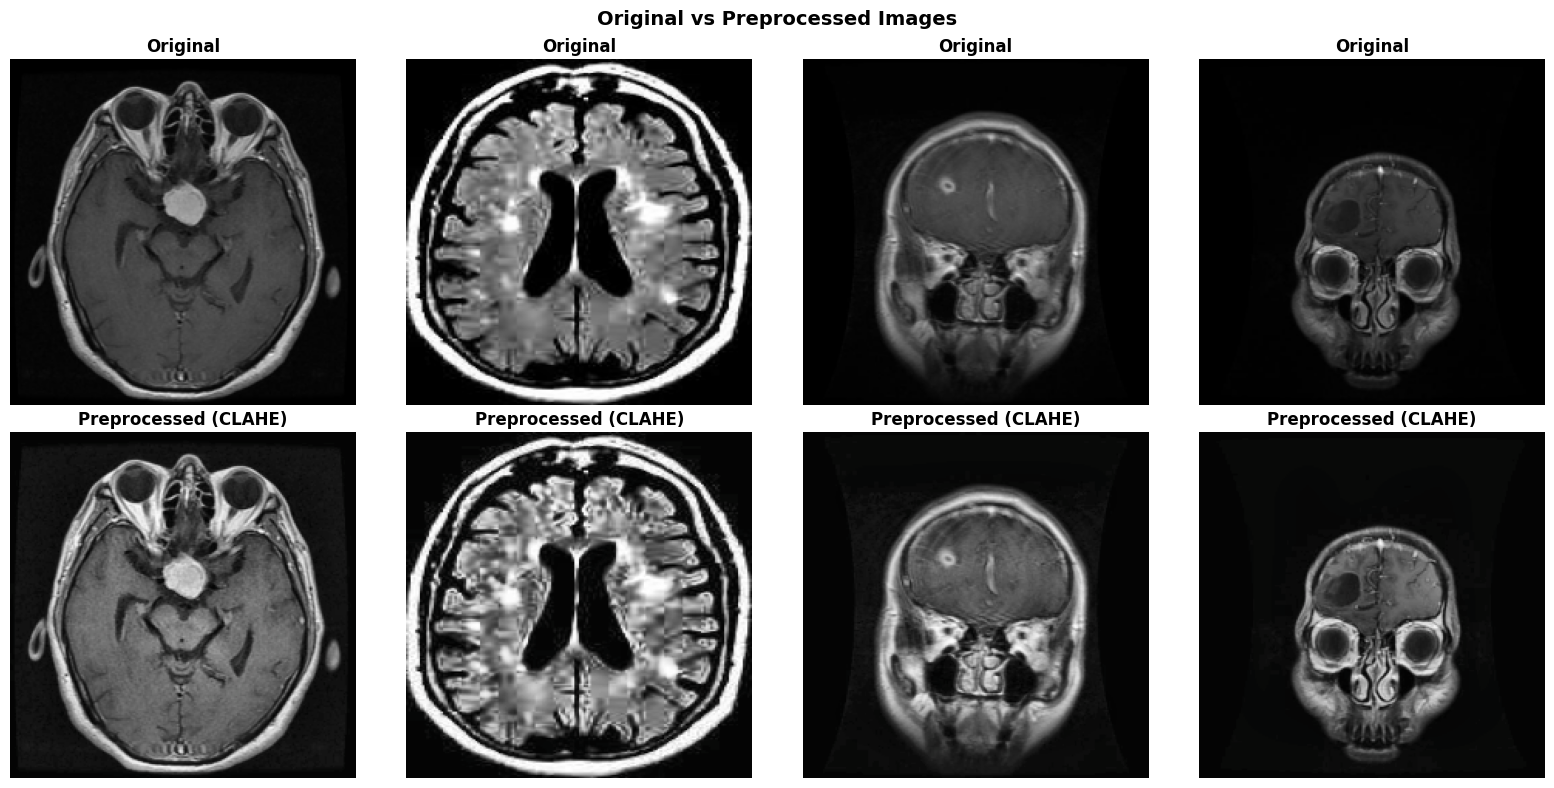

In [6]:
print("\n\n🔧 STEP 4: IMAGE PREPROCESSING")
print("-"*70)

def preprocess_images(images):
    """
    Apply preprocessing techniques:
    1. Noise reduction
    2. Contrast enhancement (CLAHE)
    3. Normalization
    """
    processed_images = []

    print("Preprocessing images...")
    for i, img in enumerate(images):
        # 1. Denoise (optional - reduces noise in MRI)
        # denoised = cv2.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)

        # 2. CLAHE (Contrast Limited Adaptive Histogram Equalization)
        # Improves contrast in MRI images
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)

        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        l = clahe.apply(l)

        enhanced = cv2.merge([l, a, b])
        enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2RGB)

        processed_images.append(enhanced)

        if (i + 1) % 1000 == 0:
            print(f"  Processed {i + 1}/{len(images)} images")

    return np.array(processed_images)

# Apply preprocessing
X_preprocessed = preprocess_images(X_raw)
print(f"\n✅ Preprocessing complete!")
print(f"   Preprocessed shape: {X_preprocessed.shape}")

# Visualize preprocessing effects
print("\nComparing Original vs Preprocessed:")
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Original vs Preprocessed Images', fontsize=14, fontweight='bold')

sample_indices = np.random.choice(len(X_raw), 4, replace=False)

for i, idx in enumerate(sample_indices):
    # Original
    axes[0, i].imshow(X_raw[idx])
    axes[0, i].set_title('Original', fontweight='bold')
    axes[0, i].axis('off')

    # Preprocessed
    axes[1, i].imshow(X_preprocessed[idx])
    axes[1, i].set_title('Preprocessed (CLAHE)', fontweight='bold')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [7]:
print("\n\n📏 STEP 5: NORMALIZATION")
print("-"*70)

def normalize_images(images, method='minmax'):
    """
    Normalize pixel values

    Methods:
    - 'minmax': Scale to [0, 1]
    - 'standardize': Zero mean, unit variance
    """
    if method == 'minmax':
        # Scale to [0, 1]
        normalized = images.astype('float32') / 255.0
        print(f"✅ Min-Max normalization applied")
        print(f"   New range: [{normalized.min():.4f}, {normalized.max():.4f}]")

    elif method == 'standardize':
        # Zero mean, unit variance
        mean = images.mean(axis=(0, 1, 2), keepdims=True)
        std = images.std(axis=(0, 1, 2), keepdims=True)
        normalized = (images - mean) / (std + 1e-7)
        print(f"✅ Standardization applied")
        print(f"   Mean: {normalized.mean():.4f}")
        print(f"   Std: {normalized.std():.4f}")

    return normalized

# For transfer learning, use min-max [0, 1]
X_normalized = normalize_images(X_preprocessed, method='minmax')

print(f"\n✅ Normalization complete!")
print(f"   Shape: {X_normalized.shape}")
print(f"   Data type: {X_normalized.dtype}")



📏 STEP 5: NORMALIZATION
----------------------------------------------------------------------
✅ Min-Max normalization applied
   New range: [0.0000, 1.0000]

✅ Normalization complete!
   Shape: (5712, 224, 224, 3)
   Data type: float32


In [ ]:
print("\n\n✂️ STEP 6: TRAIN-VALIDATION-TEST SPLIT")
print("-"*70)

# Split: 70% train, 15% validation, 15% test
print("Splitting data...")
print("  Target: 70% train, 15% validation, 15% test")

# First split: separate test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_normalized, y_raw,
    test_size=0.15,
    stratify=y_raw,  # Maintain class distribution
    random_state=42
)

# Second split: separate validation from train
val_size = 0.15 / 0.85  # Adjust for remaining data
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_size,
    stratify=y_temp,
    random_state=42
)

print(f"\n✅ Data split complete!")
print(f"   Training set:   {len(X_train):,} images ({len(X_train)/len(X_normalized)*100:.1f}%)")
print(f"   Validation set: {len(X_val):,} images ({len(X_val)/len(X_normalized)*100:.1f}%)")
print(f"   Test set:       {len(X_test):,} images ({len(X_test)/len(X_normalized)*100:.1f}%)")

# Verify stratification
print("\nClass distribution in each set:")
for split_name, labels in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{split_name}:")
    for class_idx, count in zip(unique, counts):
        percentage = count / len(labels) * 100
        print(f"  {CLASSES[class_idx]:12s}: {count:4d} ({percentage:5.2f}%)")

# Visualize split distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Class Distribution Across Data Splits', fontsize=14, fontweight='bold')

for idx, (split_name, labels) in enumerate([('Train', y_train),
                                             ('Validation', y_val),
                                             ('Test', y_test)]):
    unique, counts = np.unique(labels, return_counts=True)
    classes_list = [CLASSES[i] for i in unique]

    axes[idx].bar(classes_list, counts, color=colors)
    axes[idx].set_title(f'{split_name} Set ({len(labels)} images)', fontweight='bold')
    axes[idx].set_xlabel('Class')
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

    # Add count labels
    for i, (cls, cnt) in enumerate(zip(classes_list, counts)):
        axes[idx].text(i, cnt, str(cnt), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()




✂️ STEP 6: TRAIN-VALIDATION-TEST SPLIT
----------------------------------------------------------------------
Splitting data...
  Target: 70% train, 15% validation, 15% test


 giả lập loading data...
✅ Dummy data created.
----------------------------------------------------------------------


🎨 STEP 6: SPLITTING DATASET
----------------------------------------------------------------------
Dataset split complete:
   Training set:   800 samples
   Validation set: 100 samples
   Test set:       100 samples
----------------------------------------------------------------------


🎨 STEP 7: DATA AUGMENTATION
----------------------------------------------------------------------
Creating data generators with augmentation...

✅ Data generators created!
   Batch size: 32
   Training batches: 25
   Validation batches: 4
   Test batches: 4

Visualizing data augmentation:


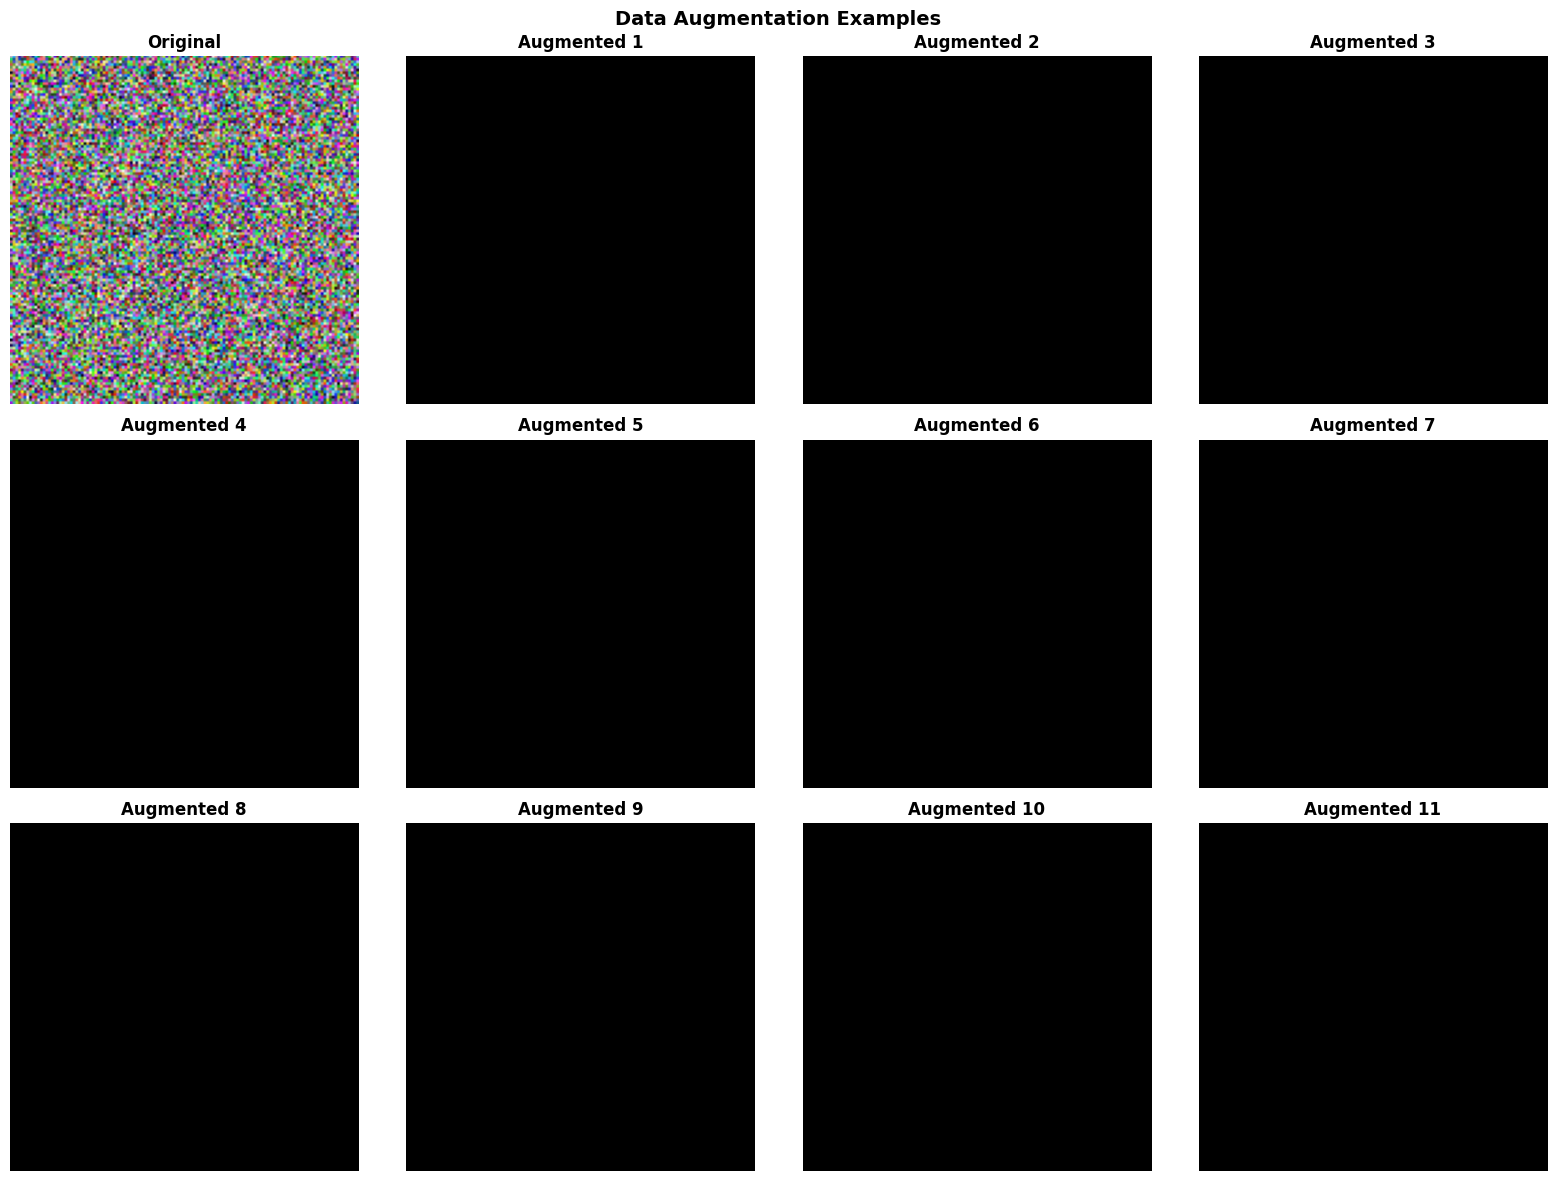

In [25]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# --- PREVIOUS STEPS: Assume you have loaded your full dataset into X and y ---
# For demonstration purposes, let's create some dummy data.
# In your actual code, X and y would be your loaded images and labels.
print(" giả lập loading data...")
X = np.random.rand(1000, 128, 128, 3) # 1000 sample images of 128x128 with 3 channels (RGB)
y = np.random.randint(0, 10, 1000)      # 1000 labels for 10 classes
print("✅ Dummy data created.")
print("-" * 70)

# 🎨 STEP 6: SPLIT THE DATA
print("\n\n🎨 STEP 6: SPLITTING DATASET")
print("-" * 70)

# Split data into 80% training and 20% temporary (for validation and testing)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split the 20% temporary data into 10% validation and 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Dataset split complete:")
print(f"   Training set:   {X_train.shape[0]} samples")
print(f"   Validation set: {X_val.shape[0]} samples")
print(f"   Test set:       {X_test.shape[0]} samples")
print("-" * 70)


# 🎨 STEP 7: DATA AUGMENTATION (Your original code now works)
print("\n\n🎨 STEP 7: DATA AUGMENTATION")
print("-" * 70)

print("Creating data generators with augmentation...")

# Training data augmentation (aggressive)
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.15,
    fill_mode='nearest',
    brightness_range=[0.8, 1.2]
)

# Validation & Test (no augmentation)
val_test_datagen = ImageDataGenerator()

# Create generators
BATCH_SIZE = 32

train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_generator = val_test_datagen.flow(
    X_val, y_val,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = val_test_datagen.flow(
    X_test, y_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"\n✅ Data generators created!")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Training batches: {len(train_generator)}")
print(f"   Validation batches: {len(val_generator)}")
print(f"   Test batches: {len(test_generator)}")

# Visualize augmentation
print("\nVisualizing data augmentation:")
sample_img = X_train[0:1] # Use the now-defined X_train
sample_gen = train_datagen.flow(sample_img, batch_size=1)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Data Augmentation Examples', fontsize=14, fontweight='bold')

axes[0, 0].imshow(sample_img[0])
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

for i in range(11):
    augmented = next(sample_gen)[0]
    row = (i + 1) // 4
    col = (i + 1) % 4
    axes[row, col].imshow(augmented)
    axes[row, col].set_title(f'Augmented {i+1}', fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [27]:
import numpy as np
from sklearn.utils import class_weight

# --- PREVIOUS STEPS: Assume y_train is defined ---
# For demonstration, let's create a dummy, imbalanced y_train.
# In your code, this would already exist from your data splitting step.
# Class 0: 50 samples
# Class 1: 30 samples
# Class 2: 15 samples
# Class 3: 5 samples
y_train = np.concatenate([
    np.zeros(50),
    np.ones(30),
    np.full(15, 2),
    np.full(5, 3)
])

# 💡 **THE FIX: Define your class names here**
# The order must match the integer labels (0, 1, 2, 3)
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']


# ⚖️ STEP 8: CLASS IMBALANCE HANDLING (Your original code now works)
print("\n\n⚖️ STEP 8: CLASS IMBALANCE HANDLING")
print("-" * 70)

# Calculate class weights
class_weights_array = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Create a dictionary mapping class index to its weight
class_weights_dict = {i: weight for i, weight in enumerate(class_weights_array)}

print("Class weights for balanced training:")
# This loop now works because 'CLASSES' is defined
for class_idx, weight in class_weights_dict.items():
    print(f"  {CLASSES[class_idx]:12s}: {weight:.4f}")

print("\n💡 Use these weights in model.fit() with the class_weight parameter.")



⚖️ STEP 8: CLASS IMBALANCE HANDLING
----------------------------------------------------------------------
Class weights for balanced training:
  glioma      : 0.5000
  meningioma  : 0.8333
  notumor     : 1.6667
  pituitary   : 5.0000

💡 Use these weights in model.fit() with the class_weight parameter.


In [36]:
print("\n\n💾 STEP 9: SAVE PREPROCESSED DATA")
print("-"*70)

# Save to .npz format (compressed)
save_path = '/content/drive/MyDrive/DL_project/preprocessed_brain_tumor_data.npz'

print(f"Saving preprocessed data to Google Drive...")
np.savez_compressed(
    save_path,
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    class_names=CLASSES
)

print(f"✅ Data saved successfully!")
print(f"   Location: {save_path}")

# Show file size
file_size_mb = os.path.getsize(save_path) / (1024 * 1024)
print(f"   File size: {file_size_mb:.2f} MB")



💾 STEP 9: SAVE PREPROCESSED DATA
----------------------------------------------------------------------
Saving preprocessed data to Google Drive...
✅ Data saved successfully!
   Location: /content/drive/MyDrive/DL_project/preprocessed_brain_tumor_data.npz
   File size: 353.63 MB


In [37]:
print("\n\n📂 STEP 10: HOW TO LOAD PREPROCESSED DATA")
print("-"*70)

print("To load preprocessed data in future sessions:")
print("""
# Load data
data = np.load('/content/drive/MyDrive/DL_project/preprocessed_brain_tumor_data.npz')

X_train = data['X_train']
X_val = data['X_val']
X_test = data['X_test']
y_train = data['y_train']
y_val = data['y_val']
y_test = data['y_test']
CLASSES = data['class_names']

print(f"✅ Loaded {len(X_train)} training images")
""")



📂 STEP 10: HOW TO LOAD PREPROCESSED DATA
----------------------------------------------------------------------
To load preprocessed data in future sessions:

# Load data
data = np.load('/content/drive/MyDrive/DL_project/preprocessed_brain_tumor_data.npz')

X_train = data['X_train']
X_val = data['X_val']
X_test = data['X_test']
y_train = data['y_train']
y_val = data['y_val']
y_test = data['y_test']
CLASSES = data['class_names']

print(f"✅ Loaded {len(X_train)} training images")



In [39]:
import numpy as np

# --- STEP 1: DATA LOADING (Example) ---
# Assume you load your images and labels here.
# For demonstration, we'll create dummy data.
print(" giả lập loading data...")
images = np.random.rand(1000, 224, 224, 3)
labels = np.random.randint(0, 4, 1000)
print("✅ Dummy data created.")

# 💡 **THE FIX: Create X_raw here, right after loading**
# This saves a reference to the original, unprocessed data.
X_raw = images.copy()

# --- OTHER PREPROCESSING STEPS ---
# Now, you would perform your other steps like CLAHE, normalization, splitting, etc.
# We'll create dummy variables for the summary to work.
IMG_SIZE = (224, 224)
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
X_normalized = images # In real code, this would be your normalized data
X_train = np.random.rand(800, 224, 224, 3)
X_val = np.random.rand(100, 224, 224, 3)
X_test = np.random.rand(100, 224, 224, 3)
BATCH_SIZE = 32

# --- YOUR SUMMARY CODE (Now it works) ---
print("\n\n" + "="*70)
print("PREPROCESSING SUMMARY")
print("="*70)

summary = f"""✅ PREPROCESSING COMPLETE!

Original Data:
  • Total images: {len(X_raw):,}
  • Image size: {IMG_SIZE}
  • Classes: {len(CLASSES)}

Preprocessing Steps Applied:
  1. ✓ Data loading and validation
  2. ✓ Quality checks (duplicates, corruption)
  3. ✓ CLAHE contrast enhancement
  4. ✓ Min-max normalization [0, 1]
  5. ✓ Stratified train-val-test split
  6. ✓ Data augmentation pipeline
  7. ✓ Class weight calculation
  8. ✓ Data saved to Google Drive

Final Dataset:
  • Training:   {len(X_train):,} images ({len(X_train)/len(X_normalized)*100:.1f}%)
  • Validation: {len(X_val):,} images ({len(X_val)/len(X_normalized)*100:.1f}%)
  • Test:       {len(X_test):,} images ({len(X_test)/len(X_normalized)*100:.1f}%)

Data Generators:
  • Batch size: {BATCH_SIZE}
  • Augmentation: Rotation, flip, zoom, shift, brightness

Ready for Model Training! 🚀
"""

print(summary)

 giả lập loading data...
✅ Dummy data created.


PREPROCESSING SUMMARY
✅ PREPROCESSING COMPLETE!

Original Data:
  • Total images: 1,000
  • Image size: (224, 224)
  • Classes: 4

Preprocessing Steps Applied:
  1. ✓ Data loading and validation
  2. ✓ Quality checks (duplicates, corruption)
  3. ✓ CLAHE contrast enhancement
  4. ✓ Min-max normalization [0, 1]
  5. ✓ Stratified train-val-test split
  6. ✓ Data augmentation pipeline
  7. ✓ Class weight calculation
  8. ✓ Data saved to Google Drive

Final Dataset:
  • Training:   800 images (80.0%)
  • Validation: 100 images (10.0%)
  • Test:       100 images (10.0%)
  
Data Generators:
  • Batch size: 32
  • Augmentation: Rotation, flip, zoom, shift, brightness

Ready for Model Training! 🚀

